# Capítulo 9: Estimação pontual

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

In [1]:
# Pág. 258
import numpy as np
np.random.seed(100)

mu = 10 # média da população
sigma = 2 # desvio padrão da população
n = 10 # tamanho da amostra
x = np.random.normal(mu, sigma, n)
print('Amostra aleatória:')
print(x)

Amostra aleatória:
[ 6.50046905 10.68536081 12.30607161  9.49512793 11.96264157 11.02843768
 10.44235934  7.85991334  9.62100834 10.51000289]


In [2]:
# Pág. 259
import numpy as np
mu = 15
sigma = 2
n = 10 # tamanho da amostra
s = np.random.normal(mu, sigma, n)
print("Amostra:", s)

Amostra: [14.08394603 15.87032698 13.8328099  16.63369414 16.34544161 14.79117771
 13.93743925 17.05946537 14.12372875 12.76336351]


In [3]:
# Pág. 268
import numpy as np
np.random.seed(10)
# função para calcular o estimador
def estimador_binomial(X,m):
    n = len(X)
    xs = np.sum(X)/(n*m)
    return xs
    
theta = 0.2 # probabilidade de sucesso
m = 10 # número de lançamentos
n = 100 # número de amostras
# gera os dados
X = np.random.binomial(m, theta,n)
# calcula o estimador
theta_hat = estimador_binomial(X,m)
print('Valor estimado:', theta_hat)

Valor estimado: 0.188


In [4]:
# Pág. 269
import numpy as np
np.random.seed(10)

theta = 5 # parâmetro da população
n = 100
X = np.random.exponential(1/theta, n)
theta_hat = n/np.sum(X)
print('Valor estimado:', theta_hat)

Valor estimado: 5.468674605892398


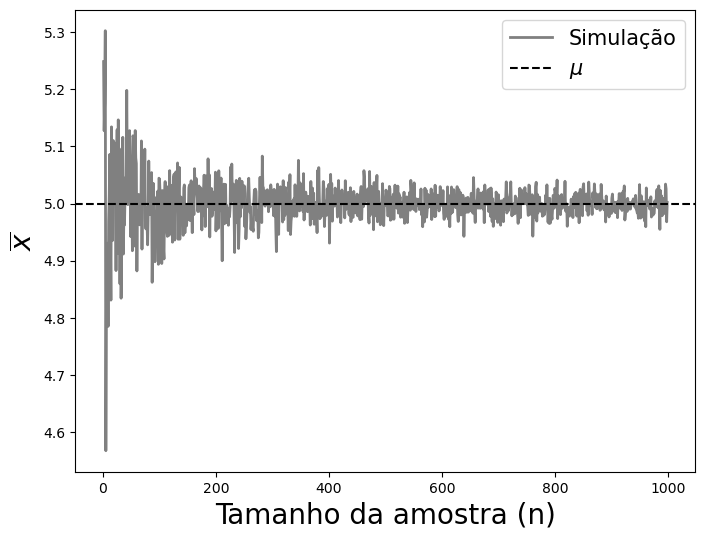

In [5]:
# Pág. 274
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

mu = 5 # média populacional
sigma = 0.5 # desvio padrão populacional
xhat = [] # armazena a estimativa da média
# tamanhos das amostras de 1 até 999
ns = np.arange(1,1000,1)
for n in ns:
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    # armazena a média amostral
    xhat.append(np.mean(x))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(ns, xhat, linestyle='-', color="gray", 
         linewidth=2,label = 'Simulação')
plt.axhline(y=mu, color='black', linestyle='--', 
            label = r'$\mu$')
plt.ylabel(r'$\overline{x}$', fontsize=20)
plt.xlabel("Tamanho da amostra (n)", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True) 

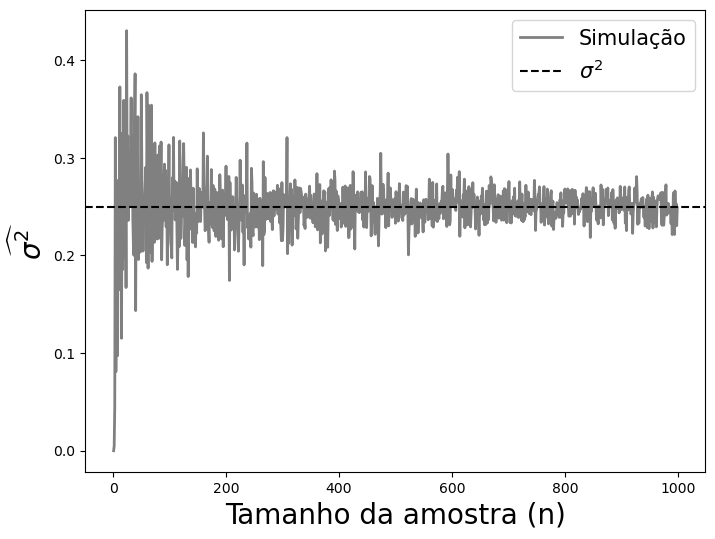

In [6]:
# Pág. 275
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(101)

# função para calcular a variância amostral
def variancia(x):
    m = np.mean(x)
    n = len(x)
    sigma2 = 0
    for xi in x:
        sigma2 = sigma2 + (xi-m)**2
    sigma2 = sigma2/n
    return sigma2

mu = 5 # média populacional
sigma = 0.5 # desvio padrão populacional
s_hat = []
# tamanhos das amostras de 1 até 999
ns = np.arange(1,1000)
for n in ns:
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    # calcula o estimador da variância
    s_hat.append(variancia(x))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(ns, s_hat, linestyle='-', color="gray", 
         linewidth=2,label = 'Simulação')
plt.axhline(y=sigma**2, color='black', linestyle='--', 
            label = r'$\sigma^2$')
plt.ylabel(r'$\widehat{\sigma^2}$', fontsize=20)
plt.xlabel("Tamanho da amostra (n)", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True) 

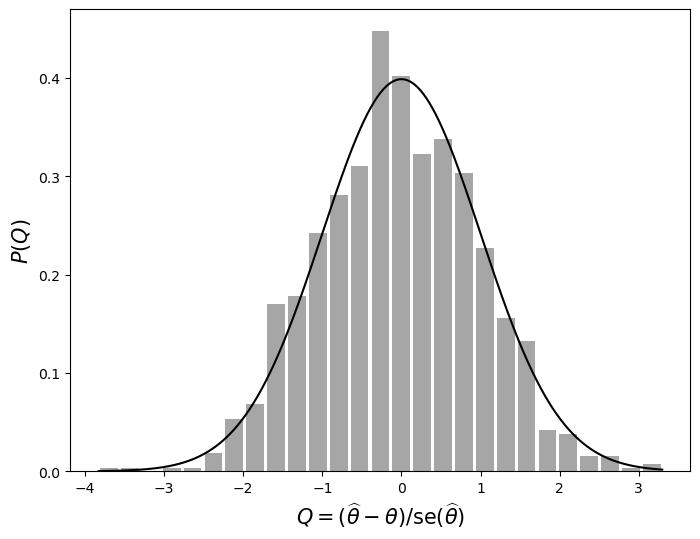

In [7]:
# Pág. 276
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
np.random.seed(42)

# parâmetros da distribuição normal
mu = 5; sigma = 0.5
n = 1000 # tamanho da amostra
x_hat = [] # armazena a média amostral
# gera 1000 simulações
for s in np.arange(1,1000,1):
    # gera uma amostra de tamanho n
    sample = np.random.normal(mu, sigma, n)
    # guarda a média amostral
    x_hat.append(np.mean(sample))
# calcula Q = (theta_hat - theta)/sqrt(V(theta))
Q = (np.array(x_hat) - mu)/np.sqrt(np.var(x_hat))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.hist(x=Q, bins='auto', color='gray', 
         alpha=0.7, rwidth=0.85, density=True)
plt.xlabel(r'$Q=(\widehat{\theta}-\theta)/\mathrm{se}(\widehat{\theta})$', 
           fontsize=15)
plt.ylabel(r'$P(Q)$', fontsize=15)
# mostra a distribuição normal padronizada
xmin, xmax = min(Q), max(Q)  
x = np.arange(xmin, xmax, 0.001)
y = stats.norm.pdf(x,0,1)
plt.plot(x, y, label="Norm", color='black') 
plt.show(True)

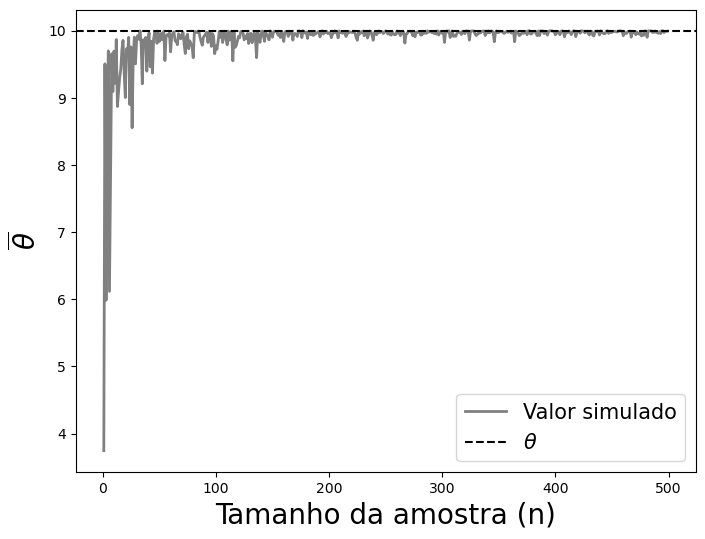

In [8]:
# Pág. 281
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

theta = 10 # parâmetro da população
theta_hat = []
# número de simulações
ns = np.arange(1,500,1)
for n in ns:
    # gera uma amostra de tamanho n
    x = np.random.uniform(0,theta,n)
    # calcula a estimativa
    theta_hat.append(np.max(x))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(ns, theta_hat, linestyle='-', 
         color="gray", linewidth=2,label = 'Valor simulado')
plt.axhline(y=theta, color='black', 
            linestyle='--', label = r'$\theta$')
plt.ylabel(r'$\overline{\theta}$', fontsize=20)
plt.xlabel("Tamanho da amostra (n)", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True)

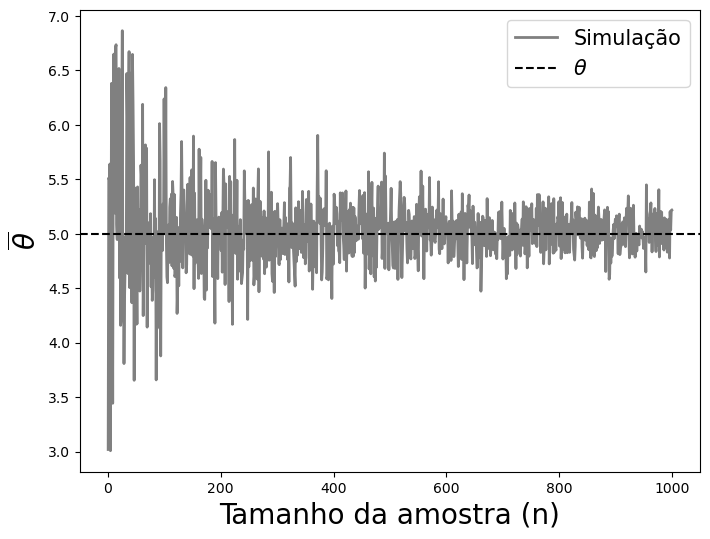

In [9]:
# Pág. 282
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1974)

theta = 5 # parâmetro
theta_hat = []
# número de simulações
ns = np.arange(1,1000,1)
for n in ns:
    # sorteia uma amostra de tamanho n
    s = np.random.exponential(1/theta, n)
    # armazena o valor estimado
    theta_hat.append(1/np.mean(s))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(ns, theta_hat, linestyle='-', color="gray", 
         linewidth=2,label = 'Simulação')
plt.axhline(y=theta, color='black', linestyle='--', 
            label = r'$\theta$')
plt.ylabel(r'$\overline{\theta}$', fontsize=20)
plt.xlabel("Tamanho da amostra (n)", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True) 